In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import superbit_lensing.utils as utils
import superbit_lensing.plotter as plotter
results_fname = "psf_leakage_results_200k.fits"
cat_dummy = Table.read(results_fname)

In [2]:
# -------------------------
# Selections (unchanged logic)
# -------------------------
cat = cat_dummy

NBIN = 10
CALIBRATE = False
MIN_COUNT = 20
njac = 30

# sel = (
# #     (cat["s2n_noshear"] > 10)
# #     & (cat["T_noshear"] / cat["Tpsf_noshear"] > 0.5)
#     (cat["gpsf"][:, 0][:, 1] > -0.05) & (cat["gpsf"][:, 0][:, 1] < 0.05)
#     & (cat["gpsf"][:, 0][:, 0] > -0.05) & (cat["gpsf"][:, 0][:, 0] < 0.05)
# )
# cat = cat[sel]

# -------------------------
# Pull arrays
# -------------------------
e1_psf = cat["gpsf"][:,0]
e2_psf = cat["gpsf"][:, 1]
# e1_gal = cat["g_th"][:, 0]
# e2_gal = cat["g_th"][:, 1]

e1_gal = cat["g"][:, 0]
e2_gal = cat["g"][:, 1]

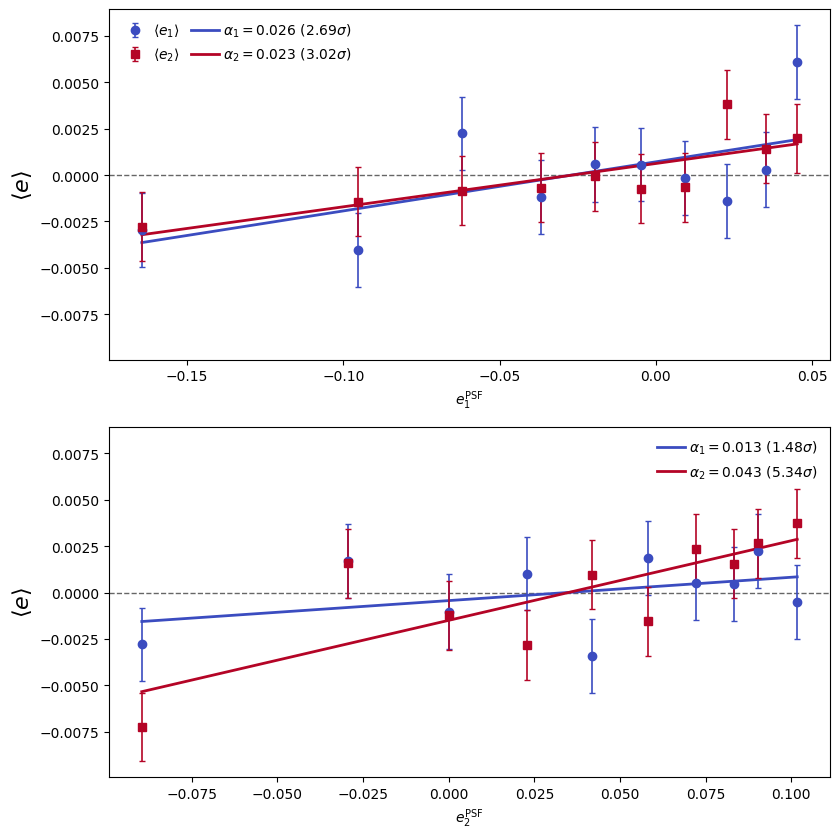

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8.5, 8.5), sharey=True)
axes = axes.ravel()

x_list = [
    (e1_psf, r"$e_{1}^{\rm PSF}$"),
    (e2_psf, r"$e_{2}^{\rm PSF}$"),
]

# -------------------------------------------------------------------------
# Usage (same flow; just instantiate once and call make_panel)
# -------------------------------------------------------------------------
paneler = plotter.PSFLeakagePanelMaker(
    e1_gal=e1_gal,
    e2_gal=e2_gal,
    NBIN=NBIN,
    MIN_COUNT=MIN_COUNT,
    CALIBRATE=CALIBRATE,
    njac=njac,
)

for ax, (x, xlab) in zip(axes, x_list):
    paneler.make_panel(
        ax,
        x_psf=x,
        xlab=xlab,
        showe1e2_leg=(ax is axes[0]),
    )

axes[0].set_ylabel(r"$\langle e \rangle$", fontsize=16)
axes[1].set_ylabel(r"$\langle e \rangle$", fontsize=16)
plt.tight_layout()

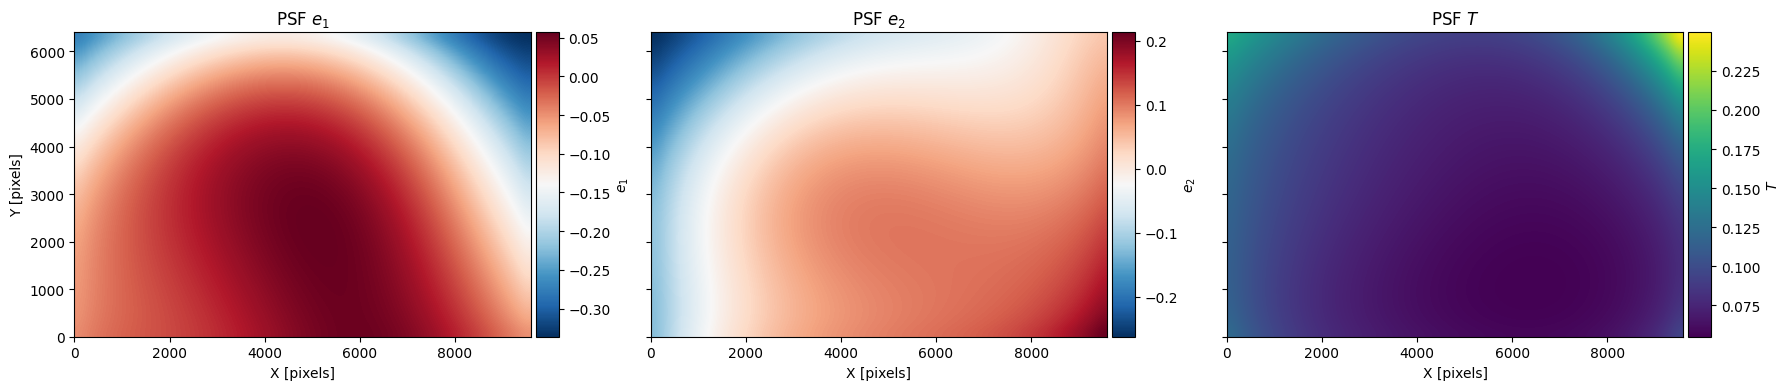

In [7]:
psfex_model_file = "/home/adfield/SHEARNET_DATA/psfex-output/Abell3411_1_300_1683033980_clean_starcat.psf"
plotter.make_psfex_shape_maps(psfex_model_file)